# EE200 Project – Question 1
## Name - Pradeep Meena
## Roll No. - 240757



# 1 . Import Required Libraries

In [25]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 2 . Load the images (cat and dog)

In [26]:

cat_image = cv2.imread('cat.jpg', 0)  # Load the cat image in grayscale
dog_image = cv2.imread('dog.jpg', 0)  # Load the dog image in grayscale

# 3. Check if images are loaded correctly

In [27]:

if cat_image is None:
    print("Cat image not found. Make sure the path is correct.")
else:
    print("Cat image loaded successfully!")

if dog_image is None:
    print("Dog image not found. Make sure the path is correct.")
else:
    print("Dog image loaded successfully!")

Cat image loaded successfully!
Dog image loaded successfully!



# 4. Plot the original cat image

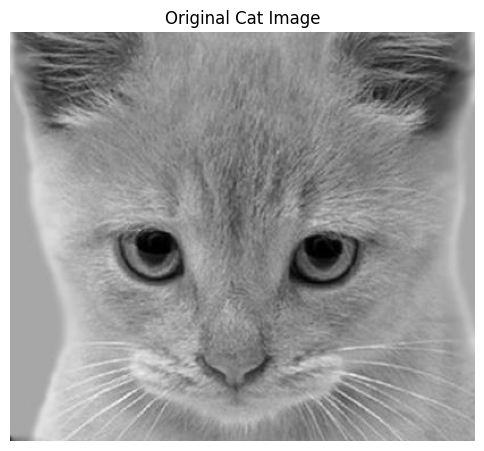

In [28]:

plt.figure(figsize=(6, 6))
plt.imshow(cat_image, cmap='gray')
plt.title('Original Cat Image')
plt.axis('off')
plt.show()


# 5. Compute the 2D Fourier Transform of the cat image

In [29]:

F_cat = np.fft.fft2(cat_image)
F_cat_shifted = np.fft.fftshift(F_cat)  # Shift zero frequency component to the center


# 6.Get the magnitude spectrum of the cat image

In [30]:

magnitude_spectrum_cat = np.abs(F_cat_shifted)

# 7.Plot the magnitude spectrum of the cat image in normal and dB scale

In [31]:


plt.figure(figsize=(12, 6))

<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

# Normal magnitude spectrum (Linear scale)

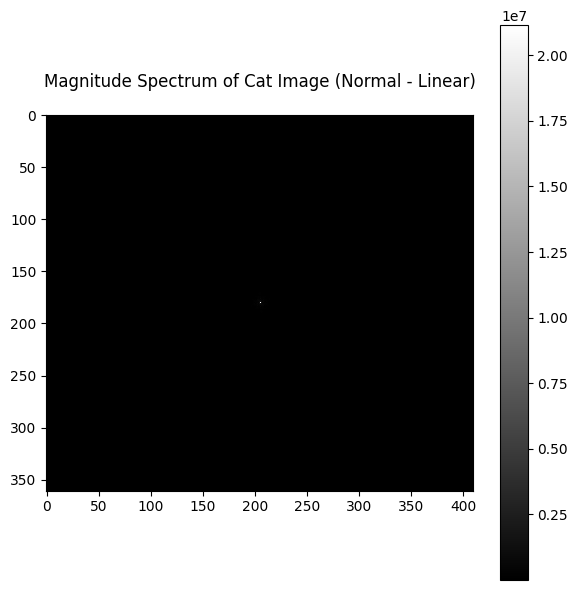

In [32]:
plt.figure(figsize=(6, 6))
plt.imshow(magnitude_spectrum_cat, cmap='gray')
plt.title('Magnitude Spectrum of Cat Image (Normal - Linear)', pad=20)  # Adjust pad to add space between title and plot
plt.colorbar()

# Adjust layout to avoid overlap
plt.tight_layout()  # Adjust the layout automatically to prevent overlap
plt.show()



# Magnitude spectrum in dB scale (logarithmic scale)

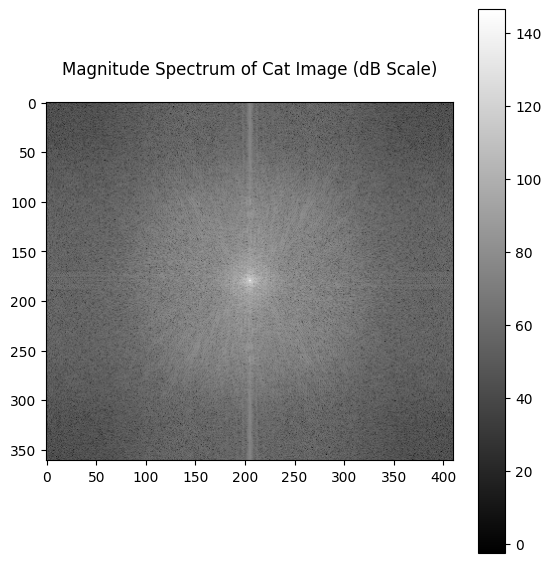

In [33]:

magnitude_spectrum_cat_db = 20 * np.log10(magnitude_spectrum_cat + 1e-6)  # Small constant to avoid log(0)
plt.figure(figsize=(6, 6))
plt.imshow(magnitude_spectrum_cat_db, cmap='gray')
plt.title('Magnitude Spectrum of Cat Image (dB Scale)', pad=20)
plt.colorbar()
plt.tight_layout(pad=2.0)
plt.show()



# 8. Rotate the cat image 90 degrees counterclockwise

In [34]:

rotated_cat_image = np.rot90(cat_image)



# 9. Compute the 2D Fourier Transform of the rotated image

In [35]:

F_rotated_cat = np.fft.fft2(rotated_cat_image)
F_rotated_cat_shifted = np.fft.fftshift(F_rotated_cat)


# 10.Get the magnitude spectrum of the rotated image

In [36]:

magnitude_spectrum_rotated_cat = np.abs(F_rotated_cat_shifted)


# 11.Plot the magnitude spectrum of the rotated cat image

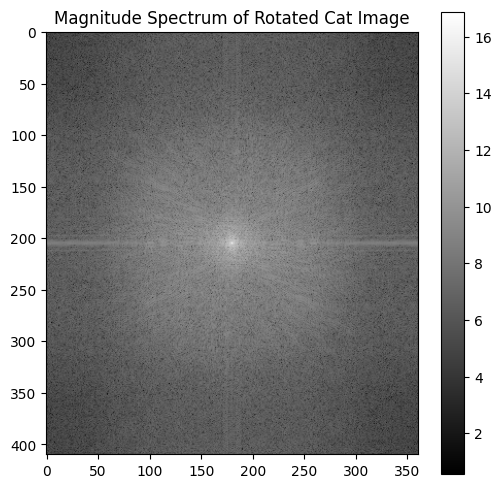

In [37]:

plt.figure(figsize=(6, 6))
plt.imshow(np.log(magnitude_spectrum_rotated_cat + 1), cmap='gray')
plt.title('Magnitude Spectrum of Rotated Cat Image')
plt.colorbar()
plt.show()


# 12.Apply Gaussian Blur to the dog image to remove high frequencies (structure)

In [38]:

dog_image_blurred = cv2.GaussianBlur(dog_image, (15, 15), 0)



# 13.Plot the low-pass (blurred) image of the dog

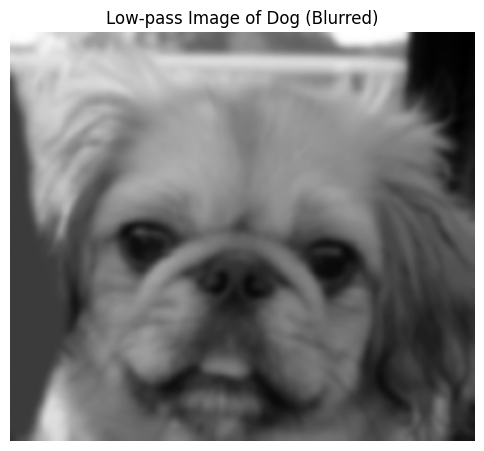

In [39]:

plt.figure(figsize=(6, 6))
plt.imshow(dog_image_blurred, cmap='gray')
plt.title('Low-pass Image of Dog (Blurred)')
plt.axis('off')
plt.show()

# 14 Compute the 2D Fourier Transform of both images (cat and blurred dog)

In [40]:

F_dog_blurred = np.fft.fft2(dog_image_blurred)
F_dog_blurred_shifted = np.fft.fftshift(F_dog_blurred)  # Shift zero frequency to the center



# 15. Frequency Fusion



# Remove high frequencies from the cat image (to retain fine details)

In [41]:

high_freq_cat = F_cat_shifted.copy()
cutoff_low, cutoff_high = 40, 150  # Adjust these values based on the image size
high_freq_cat[cutoff_low:cutoff_high, cutoff_low:cutoff_high] = 0  # Zero out low frequencies to retain high frequencies (details)




# Plot the high-pass (cat details) image after removing low frequencies

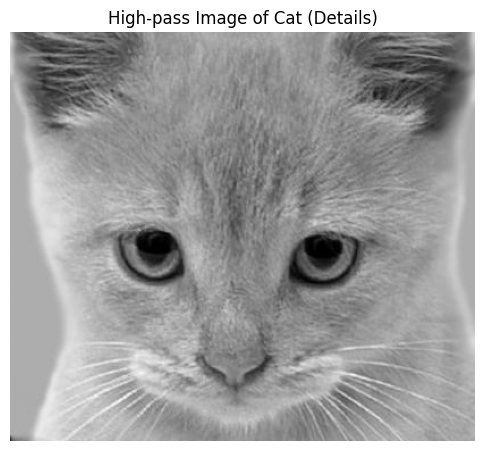

In [42]:

high_pass_cat_image = np.fft.ifft2(np.fft.ifftshift(high_freq_cat)).real
plt.figure(figsize=(6, 6))
plt.imshow(np.abs(high_pass_cat_image), cmap='gray')
plt.title('High-pass Image of Cat (Details)')
plt.axis('off')
plt.show()


# Retain low frequencies from the dog image (overall structure)

In [43]:

low_freq_dog = F_dog_blurred_shifted.copy()




# Combine the low frequencies from the dog image with high frequencies from the cat image

In [44]:

scaling_factor_cat = 1.25  # Adjust as needed for better blending
scaling_factor_dog = 2.3  # Adjust as needed for better blending
mixed_freq = scaling_factor_dog * low_freq_dog + scaling_factor_cat * high_freq_cat


# Inverse Fourier Transform to obtain the mixed image

In [45]:

mixed_image = np.fft.ifft2(np.fft.ifftshift(mixed_freq))  # Inverse shift and inverse FFT


# 16.Plot the resulting mixed image

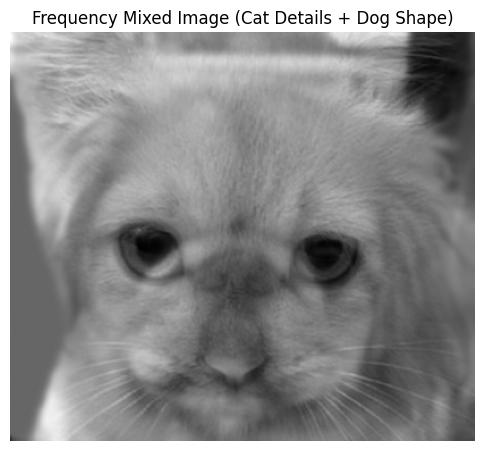

In [46]:

plt.figure(figsize=(6, 6))
plt.imshow(np.abs(mixed_image), cmap='gray')
plt.title('Frequency Mixed Image (Cat Details + Dog Shape)')
plt.axis('off')
plt.show()

# 17.Display all images in a grid

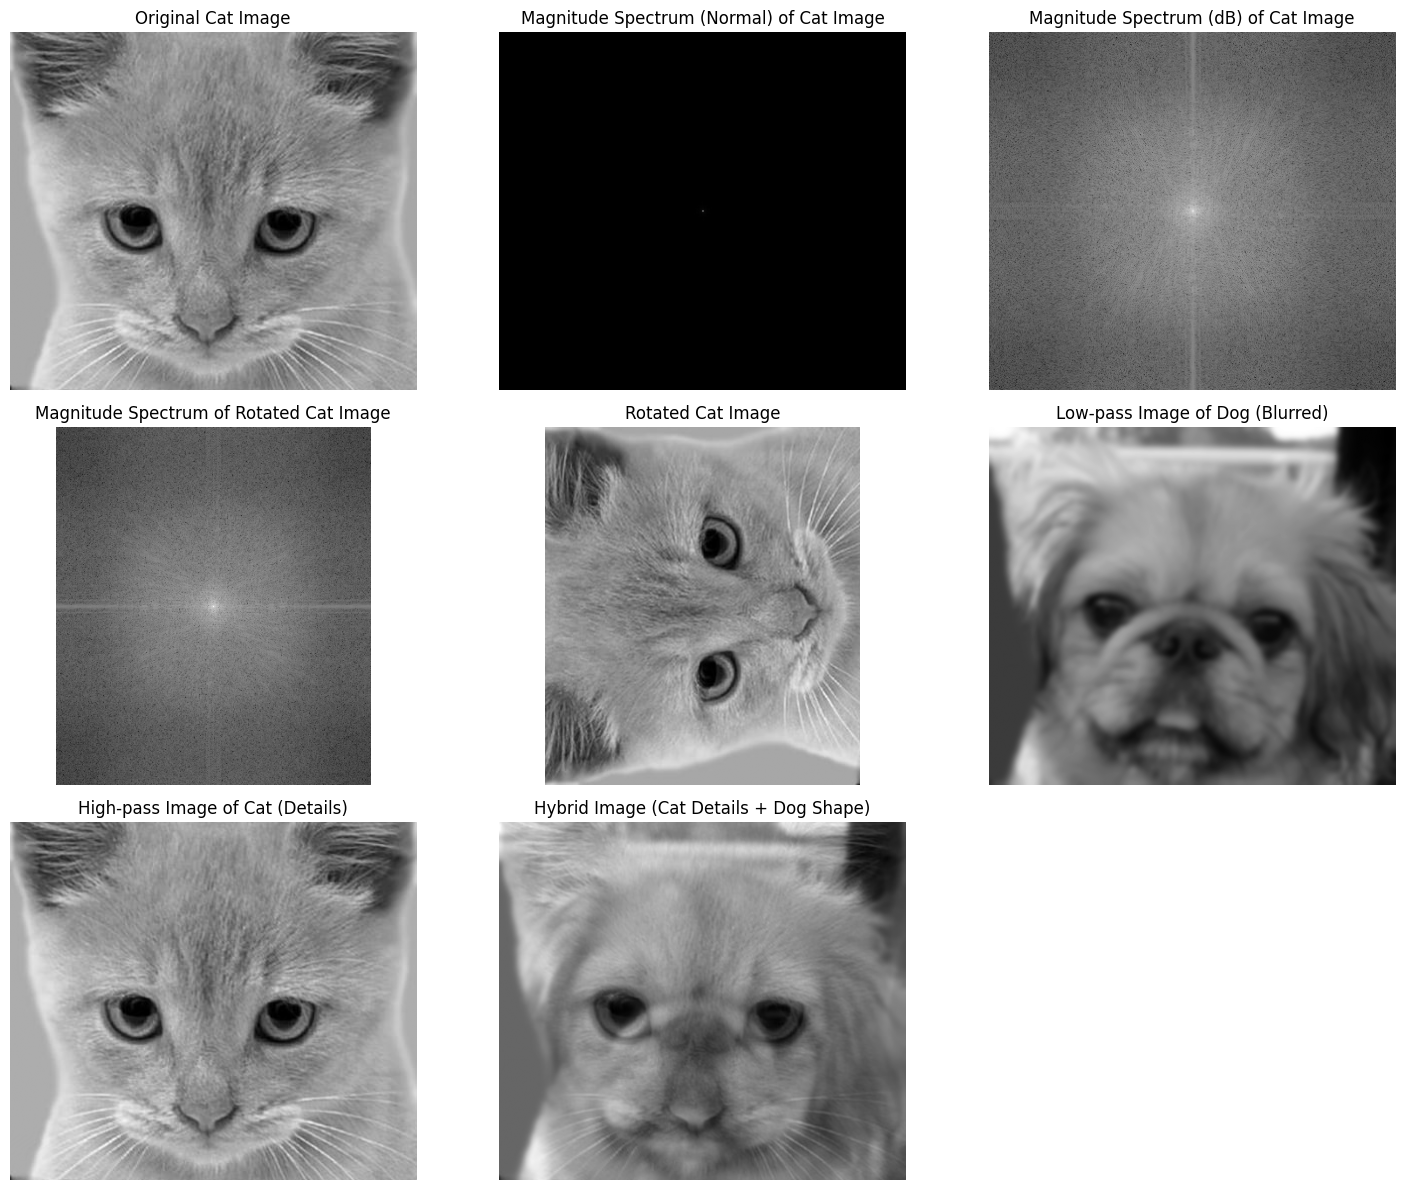

In [47]:


plt.figure(figsize=(15, 12))

# Display all intermediate results in a grid
plt.subplot(3, 3, 1)
plt.imshow(cat_image, cmap='gray')
plt.title('Original Cat Image')
plt.axis('off')

plt.subplot(3, 3, 2)
plt.imshow(magnitude_spectrum_cat, cmap='gray')
plt.title('Magnitude Spectrum (Normal) of Cat Image')
plt.axis('off')

plt.subplot(3, 3, 3)
plt.imshow(magnitude_spectrum_cat_db, cmap='gray')
plt.title('Magnitude Spectrum (dB) of Cat Image')
plt.axis('off')


plt.subplot(3,3,4)
plt.imshow(np.log(magnitude_spectrum_rotated_cat + 1), cmap='gray')
plt.title('Magnitude Spectrum of Rotated Cat Image')
plt.axis('off')

plt.subplot(3, 3, 5)
plt.imshow(rotated_cat_image, cmap='gray')
plt.title('Rotated Cat Image')
plt.axis('off')

plt.subplot(3, 3, 6)
plt.imshow(dog_image_blurred, cmap='gray')
plt.title('Low-pass Image of Dog (Blurred)')
plt.axis('off')

plt.subplot(3, 3, 7)
plt.imshow(np.abs(high_pass_cat_image), cmap='gray')
plt.title('High-pass Image of Cat (Details)')
plt.axis('off')

plt.subplot(3, 3, 8)
plt.imshow(np.abs(mixed_image), cmap='gray')
plt.title('Hybrid Image (Cat Details + Dog Shape)')
plt.axis('off')

plt.tight_layout()
plt.show()


In [48]:
print(" Observation:")
print("- The magnitude spectrum of the rotated cat image is also rotated.")
print("- The final hybrid image shows the shape of the dog and details of the cat.")
print("- Low frequencies capture global shape, high frequencies capture fine texture.")


 Observation:
- The magnitude spectrum of the rotated cat image is also rotated.
- The final hybrid image shows the shape of the dog and details of the cat.
- Low frequencies capture global shape, high frequencies capture fine texture.
